In [1]:
import pandas as pd

# Load Financial PhraseBank dataset from local raw data (100% annotator agreement)
data_path = "../data/raw/FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"

# Read the file - format is: sentence@label
sentences = []
labels = []

with open(data_path, encoding="latin-1") as f:
    for line in f:
        line = line.strip()
        if "@" in line:
            # Split from the right to handle @ in sentences
            parts = line.rsplit("@", 1)
            sentences.append(parts[0])
            labels.append(parts[1])

df = pd.DataFrame({"sentence": sentences, "label": labels})

print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")
df.head()

Dataset shape: (2264, 2)
Label distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


,sentence,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [2]:
# Phase 2: Dataset Validation & Cleaning

print("=" * 50)
print("PHASE 2: DATASET SETUP CHECKLIST")
print("=" * 50)

# 1. Check unique labels
print("\n1. Label verification:")
print(f"   Unique labels: {df['label'].unique().tolist()}")
print(f"   ✓ 3-class format (positive/neutral/negative)" if set(df['label'].unique()) == {'positive', 'neutral', 'negative'} else "   ✗ Unexpected labels found")

# 2. Check for duplicates
duplicates = df.duplicated(subset=['sentence']).sum()
print(f"\n2. Duplicates check:")
print(f"   Duplicate sentences: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates(subset=['sentence'], keep='first')
    print(f"   ✓ Removed duplicates. New shape: {df.shape}")
else:
    print(f"   ✓ No duplicates found")

# 3. Check for empty/null rows
empty_sentences = df['sentence'].isna().sum() + (df['sentence'].str.strip() == '').sum()
print(f"\n3. Empty rows check:")
print(f"   Empty/null sentences: {empty_sentences}")
if empty_sentences > 0:
    df = df[df['sentence'].str.strip() != '']
    df = df.dropna(subset=['sentence'])
    print(f"   ✓ Removed empty rows. New shape: {df.shape}")
else:
    print(f"   ✓ No empty rows found")

# 4. Final dataset summary
print("\n" + "=" * 50)
print("CLEAN DATASET SUMMARY")
print("=" * 50)
print(f"Total samples: {len(df)}")
print(f"\nLabel distribution:")
for label, count in df['label'].value_counts().items():
    pct = count / len(df) * 100
    print(f"   {label}: {count} ({pct:.1f}%)")

print("\n✓ Phase 2 Complete: Clean DataFrame ready")

PHASE 2: DATASET SETUP CHECKLIST

1. Label verification:
   Unique labels: ['neutral', 'positive', 'negative']
   ✓ 3-class format (positive/neutral/negative)

2. Duplicates check:
   Duplicate sentences: 5
   ✓ Removed duplicates. New shape: (2259, 2)

3. Empty rows check:
   Empty/null sentences: 0
   ✓ No empty rows found

CLEAN DATASET SUMMARY
Total samples: 2259

Label distribution:
   neutral: 1386 (61.4%)
   positive: 570 (25.2%)
   negative: 303 (13.4%)

✓ Phase 2 Complete: Clean DataFrame ready


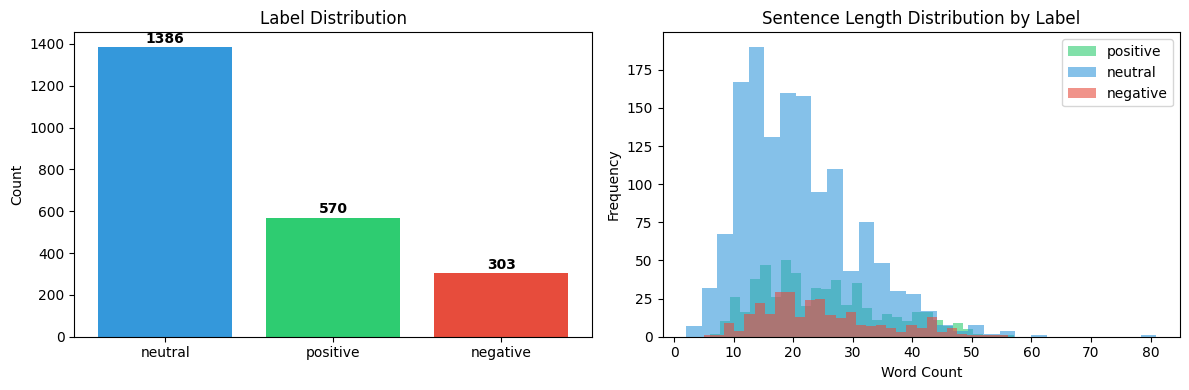


Average sentence length by label:
label
negative    24.8
neutral     20.9
positive    24.9
Name: word_count, dtype: float64


In [3]:
# EDA Visualizations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Label distribution bar chart
colors = {'positive': '#2ecc71', 'neutral': '#3498db', 'negative': '#e74c3c'}
label_counts = df['label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=[colors[l] for l in label_counts.index])
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 20, str(count), ha='center', fontweight='bold')

# 2. Sentence length distribution
df['word_count'] = df['sentence'].str.split().str.len()
for label in ['positive', 'neutral', 'negative']:
    subset = df[df['label'] == label]['word_count']
    axes[1].hist(subset, bins=30, alpha=0.6, label=label, color=colors[label])
axes[1].set_title('Sentence Length Distribution by Label')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAverage sentence length by label:")
print(df.groupby('label')['word_count'].mean().round(1))

In [4]:
# Train/Validation/Test Split
from sklearn.model_selection import train_test_split

# Encode labels
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label_encoded'] = df['label'].map(label_map)

# First split: 80% train, 20% temp
X = df['sentence'].values
y = df['label_encoded'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 50% val, 50% test (10% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Dataset splits:")
print(f"  Train: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val:   {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Save processed data
import os
os.makedirs('../data/processed', exist_ok=True)

train_df = pd.DataFrame({'sentence': X_train, 'label': y_train})
val_df = pd.DataFrame({'sentence': X_val, 'label': y_val})
test_df = pd.DataFrame({'sentence': X_test, 'label': y_test})

train_df.to_csv('../data/processed/train.csv', index=False)
val_df.to_csv('../data/processed/val.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

print("\n✓ Saved to data/processed/: train.csv, val.csv, test.csv")
print(f"\nLabel mapping: {label_map}")

Dataset splits:
  Train: 1807 samples (80.0%)
  Val:   226 samples (10.0%)
  Test:  226 samples (10.0%)

✓ Saved to data/processed/: train.csv, val.csv, test.csv

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
